# Chapitre 5 : Méthode de Newton et quasi-Newton (II)

## Partie I. Méthode de LM (Levenberg-Marquardt) (1963)

La méthode alterne entre la descente de gradient et la méthode de Newton en fonction de notre proximité avec la solution. La méthode de Levenberg-Marquardt est décrite comme suit :
$$(J_f(x)^\top J_f(x)+\lambda.I)\Delta x = -\nabla f(x)$$
$I$ représente la matrice identité, $J_f$ est la matrice jacobienne et $\lambda$ est le coefficient d'amortissement. Ce paramètre permet à l'algorithme de passer de la méthode de Newton à la descente de gradient. Lorsque $\lambda$ est petit, la méthode utilise un pas de Newton. Lorsque $\lambda$ est grand, elle suit la descente de gradient. Habituellement, la première valeur de $\lambda$ est plus grande, ce qui entraîne un premier pas dans la direction de la descente de gradient. Cette approche repose sur le fait que la méthode de Newton est plus efficace vers la fin des itérations, tandis que la descente de gradient est plus utile au début du processus, lorsque la solution idéale est encore éloignée.

Nous donnons ici l'organigramme de cet algorithme, et son code d'implémentation peut faire référence aux codes de la méthode de descente de gradient et de la méthode de Newton.

<img src="LM.png" alt="image_description" width="500">

## Partie II. Méthode de Quasi-Newton

En bref, la méthode quasi-Newton est une méthode simplifiée de calcul de l'inverse de la matrice hessienne.
L'approximation de Taylor d'ordre 1 $$\nabla f(x) = \nabla f(x_{k+1}) + H_f(x_{k+1})\cdot(x-x_{k+1}) + \mathcal{O}(\|x-x_{k+1}\|^2)$$

Si $x = x_k$, $\Delta_k = x_{k+1} - x_k$, $\gamma_k = \nabla f(x_{k+1})-\nabla f(x_k)$, on obtient $$H_f(x_{k+1})\cdot\Delta_k+\mathcal{O}(\|\Delta_k\|^2) = \gamma_k$$
avec $H_f(x_{k+1})=H_{k+1}$.

Nous couvrirons deux méthodes :
1. Lorsque la matrice inverse de la matrice hessienne est difficile à résoudre, on utilise l'algorithme DFP (Davidson-Fletcher-Powell)
$$G_k \approx H_k$$
$$G_{k+1}\cdot\Delta_k = \gamma_k$$
2. Lorsque la matrice Hessienne elle-même n'existe pas, ou que sa matrice inverse n'existe pas, on utilise l'algorithme BFGS (Broyden-Fletcher-Goldfarb-Shanno)
$$B_k \approx H_k^{-1}$$
$$B_{k+1}\cdot\gamma_k = \Delta_k$$

### I.1. Algorithme DFP (Davidson-Fletcher-Powell) (1964)

On suppose que $$G_{k+1}=G_k+\Delta G_k = G_k+\alpha.u\cdot u^{\top}+\beta.v\cdot v^{\top}$$
avec les constants $(\alpha,\beta)\in(\mathbb R)^2$ et les vecteurs $(u,v)\in(\mathbb R^n)^2$, on peut toujours établir une nouvelle matrice symétrique.

Alors, on a $$G_{k+1}\cdot\Delta_k = \left(G_k+\alpha.u\cdot u^{\top}+\beta.v\cdot v^{\top}\right)\cdot\Delta_k = \gamma_k$$
Par changement de l'ordre des vecteurs dans la fonction,
$$G_k\cdot\Delta_k+u\underbrace{\left(\alpha.u^{\top}\cdot\Delta_k\right)}_{scalaire}+v\underbrace{\left(\beta.v^{\top}\cdot\Delta_k\right)}_{scalaire} = \gamma_k$$

Soit les deux termes scalaires $\alpha.u^{\top}\cdot\Delta_k=1$ et $\beta.v^{\top}\cdot\Delta_k=-1$. Il existe toujours les constants $\alpha = \frac{1}{u^{\top}\cdot\Delta_k}$ et $\beta=-\frac{1}{v^{\top}\cdot\Delta_k}$. 

Ainsi, l'équation précédente est 
$$G_k\cdot\Delta_k+u-v=\gamma_k$$
satisfaisant avec $u=\gamma_k$ et $v=G_k\cdot\Delta_k$. On peut ensuite fixer les constants $\alpha$ et $\beta$.
\begin{align*}
\alpha &= \frac{1}{\gamma_k^{\top}\cdot\Delta_k} \\
\beta &= -\frac{1}{\Delta_k^{\top}\cdot G_k^{\top}\cdot\Delta_k}
\end{align*}

Finalement, on a 
$$G_{k+1}=G_{k}+\dfrac{\gamma_{k}\cdot \gamma_{k}^{\top}}{\gamma_{k}^{\top}\cdot \Delta_{k} }- \dfrac{G_{k}\cdot\Delta_{k}\cdot\Delta_{k}^{\top}\cdot G_{k}}{\Delta_{k}^{\top}\cdot G_{k}\cdot\Delta_{k}}$$

### I.2. Algorithme BFGS (Broyden-Fletcher-Goldfarb-Shanno) (1970)

<img src="BFGS.jpg" alt="image_description" width="300">

De même, on suppose que $$B_{k+1}=B_k+\Delta B_k = B_k+\alpha.u\cdot u^{\top}+\beta.v\cdot v^{\top}$$

Avec une démonstration similaire, la formule itérative de la matrice $B_{k+1}$ peut être donnée par
$$B_{k+1}=B_{k}+\dfrac{\Delta_{k} \cdot \Delta_{k}^{\top}}{\Delta_{k}^{\top}\cdot \gamma_{k}}- \dfrac{B_{k}\cdot\gamma_{k}\cdot\gamma_{k}^{\top}\cdot B_{k}}{\gamma_{k}^{\top}\cdot B_{k}\cdot \gamma_{k}}$$

### I.3. Exercices

On refait les exercices : trouver les zéros des fonction $$f_1(x) = e^{2x}-e$$ et $$f_2(x_1,x_2)=(x_1^2+x_2^2-2,x_1^2-x_2^2-1)$$ avec la méthode de quasi-Newton.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Entrée : x0 = point initial
#          N = nombre maximum d'itérations
#          f = fonction (gradient)
#          eps = tolérance
# Sortie : (sortie 1) = tous les points
#          (sortie 2) = toutes les valeurs de fonction f
#          (sortie 3) = pas de convergence

def Newton_DFP(x0,N,f,eps):
    it = 0 #itmax = N
    x = x0
    fx = f(x0)
    G = 1 # matrice initiale
    liste_x = np.zeros(N+1)
    liste_fx = np.zeros(N+1)
    liste_x[0] = x0
    liste_fx[0] = f(x0)
    while np.abs(fx) > eps and it < N:
        it += 1
        fx = f(x)
        Delta = -G*fx
        x = x + Delta
        fx_new = f(x)
        gamma = fx_new - fx
        G = G + Delta**2/(Delta*gamma)-(G**2*gamma**2)/(gamma**2*G)
        liste_x[it] = x
        liste_fx[it]= fx
    return liste_x,liste_fx,it

In [3]:
# Entrée : x0 = point initial
#          N = nombre maximum d'itérations
#          f = fonction (gradient)
#          eps = tolérance
# Sortie : (sortie 1) = tous les points
#          (sortie 2) = toutes les valeurs de fonction f
#          (sortie 3) = pas de convergence

def Newton_BFGS(x0,N,f,eps):
    it=0 #itmax = N
    x=x0
    fx=f(x0)
    B = 1 # matrice initiale
    liste_x=np.zeros(N+1)
    liste_fx=np.zeros(N+1)
    liste_x[0]=x0
    liste_fx[0]=f(x0)
    while np.abs(fx) > eps and it < N:
        it+=1
        fx = f(x)
        Delta = -fx/B
        x = x + Delta
        fx_new = f(x)
        gamma = fx_new - fx
        B = B + gamma**2/(Delta*gamma)-(B**2*Delta**2)/(Delta**2*B)
        liste_x[it] = x
        liste_fx[it]= fx
    return liste_x,liste_fx,it

In [4]:
def f1(x): # le gradient, on n'a pas besoin de la hessienne df1 ici
    return x**2-3*x

In [5]:
# Test de quasi-Newton avec f1
x0 = -1
N = 20
f = f1
eps = 1e-6

La méthode converge en  8 pas


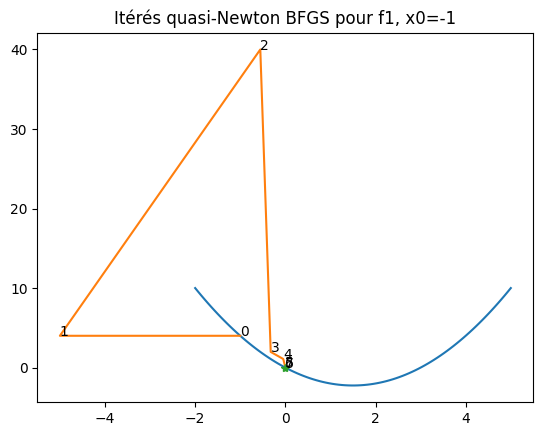

In [6]:
tabx,tabfx,it = Newton_DFP(x0,N,f,eps) 
print('La méthode converge en ',it,'pas')

tabxeff = tabx[:it]
tabfxeff = tabfx[:it]

t = np.linspace(-2,5,100) # Graphe de f1
yt = f1(t)
plt.plot(t,yt,tabxeff,tabfxeff,tabxeff[-1],tabfxeff[-1],'*')
for i in range(it):
    plt.text(tabxeff[i],tabfxeff[i],s=str(i))
plt.title('Itérés quasi-Newton BFGS pour f1, x0=-1')
plt.show()

La méthode converge en  8 pas


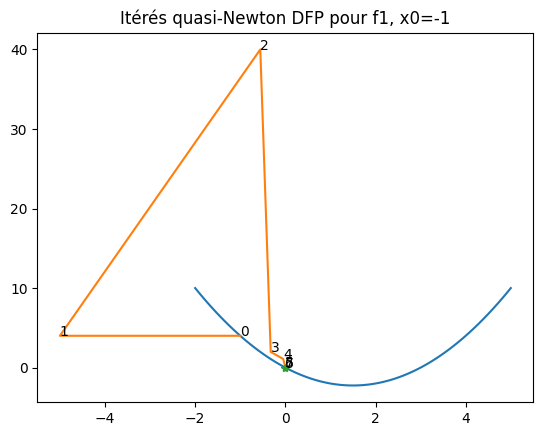

In [7]:
tabx,tabfx,it=Newton_BFGS(x0,N,f,eps) 
print('La méthode converge en ',it,'pas')

tabxeff=tabx[:it]
tabfxeff=tabfx[:it]

t=np.linspace(-2,5,100) # Graphe de f1
yt=f1(t)
plt.plot(t,yt,tabxeff,tabfxeff,tabxeff[-1],tabfxeff[-1],'*')
for i in range(it):
    plt.text(tabxeff[i],tabfxeff[i],s=str(i))
plt.title('Itérés quasi-Newton DFP pour f1, x0=-1')
plt.show()

In [8]:
# Entrée : x0 = point initial
#          N = nombre maximum d'itérations
#          f = fonction (gradient)
#          eps = tolérance
# Sortie : (sortie 1) = tous les points
#          (sortie 2) = toutes les valeurs de fonction f
#          (sortie 3) = pas de convergence

def Newton_DFP_multi(x0,N,f,eps):
    it = 0 #itmax = N
    x = x0
    fx = f(x0)
    G = np.identity(len(x)) # matrice initiale
    liste_x = np.zeros(N+1)
    liste_y = np.zeros(N+1)
    liste_fx = np.zeros(N+1)
    liste_fy = np.zeros(N+1)
    liste_crit = np.zeros(N+1)
    liste_it = np.zeros(N+1)
    liste_x[0] = x[0]
    liste_y[0] = x[1]
    crit = abs(np.linalg.norm(fx))
    liste_fx[0] = fx[0]
    liste_fy[0] = fx[1]
    liste_it[0] = 0
    liste_crit[0] = crit
    while crit > eps and it < N:
        it+=1
        fx = f(x)
        Delta = -np.dot(G,fx)
        x = x + Delta
        fx_new = f(x)
        crit = abs(np.linalg.norm(fx_new))
        gamma = np.array([fx_new[0] - fx[0],fx_new[1] - fx[1]])
        G = G + np.outer(Delta,Delta)/np.dot(Delta.T,gamma)-(np.dot(np.outer(np.dot(G,gamma),gamma),G))/(np.dot(np.dot(gamma.T,G),gamma))
        liste_x[it] = x[0]
        liste_y[it] = x[1]
        liste_fx[it]= fx_new[0]
        liste_fy[it]= fx_new[1]
        liste_crit[it] = crit
        liste_it[it]= it
    return liste_x,liste_y,liste_fx,liste_fy,liste_crit,liste_it,it

In [9]:
def f2(x):
    x1=x[0]
    x2=x[1]
    y1=x1**2+x2**2-2
    y2=x1**2-x2**2-1
    return y1,y2

La méthode converge en  8 pas


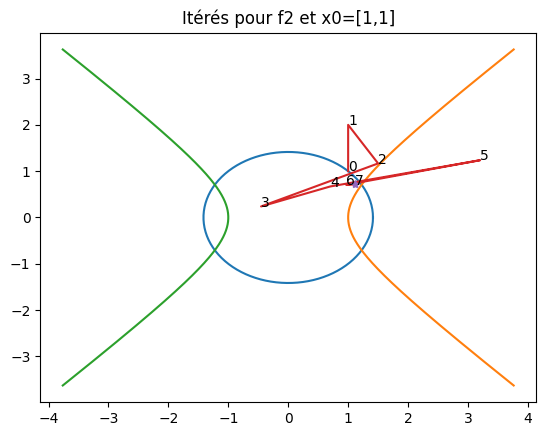

In [10]:
tabx,taby,tabfx,tabfy,tabcrit,tabit,it=Newton_DFP_multi(np.array([1,1]),100,f2,0.1)
print('La méthode converge en ',it,'pas')


tabxeff=tabx[:it]
tabyeff=taby[:it]
tabfxeff=tabfx[:it]
tabfyeff=tabfy[:it]

t = np.linspace(0,2*np.pi,100) # le cercle
r = np.sqrt(2)
xt = r*np.cos(t)
yt = r*np.sin(t)

s = np.linspace(-2,2,600) # l'hyperbole
xs = np.cosh(s)
ys = np.sinh(s)

plt.plot(xt,yt)
plt.plot(xs,ys)
plt.plot(-xs,ys)
plt.plot(tabxeff,tabyeff)
plt.plot(tabxeff[-1],tabyeff[-1],'*')
for i in range(it):
    plt.text(tabxeff[i],tabyeff[i],s=str(i))
plt.title('Itérés quasi-Newton BFGS pour f1, x0=-1')
plt.title('Itérés pour f2 et x0=[1,1]')
plt.show()

Package
https://docs.scipy.org/doc/scipy-1.10.0/reference/optimize.minimize-cg.html

### I.4. Algorithme L-BFGS (Limited-memory BFGS) (1980)

Comme l'approximation de la matrice hessienne est $H_{k+1}\approx B_{k+1}^{-1}$, nous avons
$$H_{k+1}^{\text{BFGS}} = H_k + \left(1+\frac{\gamma_k^\top \cdot H_k \cdot \gamma_k}{\Delta_k^\top \cdot \gamma_k} \right)\frac{\Delta_k \cdot \Delta_k^\top}{\Delta_k^\top \cdot \gamma_k} - \frac{\Delta_k \cdot \gamma_k^\top \cdot H_k + H_k \cdot \gamma_k \cdot \Delta_k^\top}{\Delta_k^\top \cdot \gamma_k}$$

Par conséquent, nous pouvons constater que chaque itération de la méthode quasi-Newton n’a besoin que de connaître le $H_k$ précédent pour itérer un nouveau $x_{k+1}$, sans avoir besoin de trouver l’inverse de la matrice hessienne.

Chaque calcul d'itération dans l'algorithme BFGS nécessite la matrice obtenue à partir de l'itération précédente. L'espace de stockage requis pour cette matrice est d'au moins $\frac{N(N+1)}{2}$. Sur la base du $H_k^{\text{BFGS}}$ que nous avons dérivé précédemment, nous pouvons le dériver davantage pour réduire l'espace de stockage requis pour le fonctionnement de l'algorithme.

\begin{align}
H_{k+1}^{\text{BFGS}} 
&= H_k + \left(1+\frac{\gamma_k^\top \cdot H_k \cdot \gamma_k}{\Delta_k^\top \cdot \gamma_k} \right)\frac{\Delta_k \cdot \Delta_k^\top}{\Delta_k^\top \cdot \gamma_k} - \frac{\Delta_k \cdot \gamma_k^\top \cdot H_k + H_k \cdot \gamma_k \cdot \Delta_k^\top}{\Delta_k^\top \cdot \gamma_k} \\
&= H_k + \frac{\left(\Delta_k - H_k \cdot \gamma_k\right)\cdot\Delta_k^\top + \Delta_k \cdot \left(\Delta_k - H_k \cdot \gamma_k\right)^\top}{\Delta_k^\top \cdot \gamma_k} - \frac{\left(\Delta_k - H_k \cdot \gamma_k\right)^\top \cdot \gamma_k}{\left(\Delta_k^\top \cdot \gamma_k\right)^2} . \Delta_k \cdot \Delta_k^\top \\
&= \left(I - \frac{\Delta_k \cdot \gamma_k^\top}{\Delta_k^\top \cdot \gamma_k}\right) \cdot H_k \cdot \left(I - \frac{\gamma_k \cdot \Delta_k^\top}{\Delta_k^\top \cdot \gamma_k}\right) + \frac{\Delta_k \cdot \Delta_k^\top}{\Delta_k^\top \cdot \gamma_k}
\end{align}


Soit $\rho_k=\frac{1}{\Delta_k^\top\cdot \gamma_k}$, $V_k=\left(I-\rho_k\cdot \gamma_k \cdot \Delta_k^\top\right)$, nous pouvons obtenir
$$H_{k+1} = V_k^\top \cdot H_k \cdot V_k + \rho_k \cdot \Delta_k \cdot \Delta_k^\top$$
Développez cette formule et prenez les m premiers termes comme approximation, nous pouvons obtenir
\begin{align}
H_{k+1} 
&= V_k^\top \cdot V_{k-1}^\top \cdots V_{k-m+1}^\top \cdot H_0 \cdot V_{k-m+1} \cdots V_{k-1} \cdot V_k^\top \\
&+ V_k^\top \cdots V_{k-m+2}^\top \cdot \rho_{k-m+1} \cdot \Delta_{k-m+1} \cdot \Delta_{k-m+1}^\top \cdot V_{k-m+2} \cdots V_k^\top \\
&+ \cdots \\
&+ V_k^\top \cdot \rho_{k-1} \cdot \Delta_{k-1} \cdot \Delta_{k-1}^\top \cdots V_k^\top \\
&+ \rho_{k} \cdot \Delta_{k} \cdot \Delta_{k}^\top
\end{align}
Puisque $\rho$ et $V$ peuvent aussi être calculés à partir des deux vecteurs $\Delta$ et $\gamma$. Par conséquent, il suffit de stocker les $m$ derniers vecteurs $\Delta$ et $\gamma$, plus la matrice diagonale $H_0$. Un total de $2(m+1)$ vecteurs à $N$ dimensions doivent être stockés. Lorsque la valeur de $m$ est petite et la valeur de $N$ est grande, l'espace de stockage requis pour le calcul est beaucoup plus petit que la matrice hessienne.